# Tìm cấu hình để DBSCAN phân cụm được

## Vấn đề gốc

Ở các notebook trước, DBSCAN trả về **một cụm khổng lồ chiếm 86–88% dữ liệu** — thuật toán chỉ nói "Manhattan là một hotspot", không tách được các vùng đón riêng lẻ. Ban đầu tôi nghĩ đây là chuyện chọn sai khung giờ.

Notebook này kiểm chứng điều đó, và kết luận hoá ra **không phải vậy**.

## Ba cái bẫy khi so sánh

| Bẫy | Vì sao | Cách xử lý |
|---|---|---|
| Ca ít dữ liệu "dễ cụm" | 3h sáng chỉ vài nghìn chuyến — dễ tách chỉ vì ít điểm | Lấy mẫu **cùng số điểm** cho mọi ca |
| Ca thiếu dữ liệu bị bỏ qua âm thầm | Không đủ điểm thì bỏ, kết luận thiên lệch | Đếm và **báo cáo rõ** số ca bị loại |
| Nhiều cụm nhỏ ≠ nhiều hotspot | 800 cụm với 0 cụm lớn là kết quả tệ | Đo `useful` = số cụm chứa ≥ 1% dữ liệu |

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / "src" / "hotspot").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src" / "hotspot").exists():
    raise FileNotFoundError("Khong tim thay src/hotspot")
sys.path.insert(0, str(ROOT / "src"))

from hotspot import FilterSpec, cluster_table, filter_pickups, load_dataset, run_dbscan
from hotspot.filters import WEEKDAY_NAMES

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

DOW = list(WEEKDAY_NAMES)
MIN_PTS = 15
N_SAMPLE = 20_000      # 20k: phu duoc 112/168 ca (30k chi 66/168)
EPS_GRID = [40, 50, 60, 70, 80]
TOP_LIMIT = 50.0       # cum lon nhat phai nho hon
MIN_USEFUL = 3         # va it nhat 3 cum chua >= 1% du lieu
SEED = 42

print(f"N_SAMPLE={N_SAMPLE:,} | MinPts={MIN_PTS} | eps={EPS_GRID}")
print(f"Dat khi: cum lon nhat < {TOP_LIMIT}% VA >= {MIN_USEFUL} cum >= 1%")

N_SAMPLE=20,000 | MinPts=15 | eps=[40, 50, 60, 70, 80]
Dat khi: cum lon nhat < 50.0% VA >= 3 cum >= 1%


---

## 1. Hàm đánh giá một kết quả

`top_share` là chỉ báo quyết định: nếu một cụm nuốt > 50% dữ liệu thì thuật toán chỉ nói "chỗ này đông", chưa tách được vùng nào.

In [2]:
def evaluate(sample: pd.DataFrame, eps_m: float, min_samples: int = MIN_PTS) -> dict:
    """Chay DBSCAN, tra ve cac chi bao de quyet dinh ket qua co dung y nghia khong."""
    result = run_dbscan(sample, eps_m, min_samples)
    lab = sample.assign(_label=result.labels)
    clustered = lab[lab["_label"] != -1]

    n = len(sample)
    top_share = (clustered["_label"].value_counts().iloc[0] / n * 100
                 if len(clustered) else 100.0)
    useful = int((clustered["_label"].value_counts() >= 0.01 * n).sum())

    return {
        "eps_m": int(eps_m),
        "n_clusters": result.n_clusters,
        "noise_pct": round(result.noise_pct, 1),
        "top_share": round(top_share, 1),
        "useful": useful,
        "ok": bool(top_share < TOP_LIMIT and useful >= MIN_USEFUL),
    }


df = load_dataset("full")
print(f"Dataset: {len(df):,} diem don hop le")

demo = filter_pickups(df, FilterSpec(weekdays=(4,), hour_start=17, hour_end=19))
demo = demo.sample(min(20_000, len(demo)), random_state=SEED)
print(f"\nVi du: Th 5 17-18h, {len(demo):,} diem")
for e in EPS_GRID:
    print(" ", evaluate(demo, e))

Dataset: 4,449,041 diem don hop le

Vi du: Th 5 17-18h, 20,000 diem
  {'eps_m': 40, 'n_clusters': 136, 'noise_pct': 75.8, 'top_share': np.float64(1.0), 'useful': 0, 'ok': False}


  {'eps_m': 50, 'n_clusters': 163, 'noise_pct': 61.0, 'top_share': np.float64(8.4), 'useful': 1, 'ok': False}
  {'eps_m': 60, 'n_clusters': 143, 'noise_pct': 51.0, 'top_share': np.float64(12.0), 'useful': 4, 'ok': True}
  {'eps_m': 70, 'n_clusters': 108, 'noise_pct': 39.7, 'top_share': np.float64(28.1), 'useful': 6, 'ok': True}
  {'eps_m': 80, 'n_clusters': 95, 'noise_pct': 32.5, 'top_share': np.float64(33.4), 'useful': 7, 'ok': True}


---

## 2. Quét 168 khung giờ × 5 giá trị `eps`

Mọi ca được lấy mẫu về đúng `N_SAMPLE` điểm trước khi chạy DBSCAN.

In [3]:
rng = np.random.default_rng(SEED)
rows = []
t0 = time.time()

for dow in range(7):
    for hour in range(24):
        window = df[(df["weekday"] == dow) & (df["hour"] == hour)]
        if len(window) < N_SAMPLE:
            continue                      # KHONG du du lieu de so sanh
        for eps in EPS_GRID:
            sample = window.iloc[
                np.sort(rng.choice(len(window), N_SAMPLE, replace=False))
            ]
            rows.append({"dow": dow, "hour": hour,
                         "n_window": len(window), **evaluate(sample, eps)})
    print(f"  xong {DOW[dow]} ({time.time() - t0:.0f}s)")

ok = pd.DataFrame(rows)
n_win = ok.groupby(["dow", "hour"]).ngroups
print(f"\n{len(ok)} cau hinh | {n_win}/168 ca so sanh duoc | {time.time() - t0:.0f}s")

  xong Th 2 (4s)


  xong Th 3 (10s)


  xong Th 4 (15s)


  xong Th 5 (20s)


  xong Th 6 (25s)


  xong Th 7 (29s)


  xong CN (33s)

560 cau hinh | 112/168 ca so sanh duoc | 33s


In [4]:
cnt = df.groupby(["weekday", "hour"]).size().rename("n").reset_index()
short = cnt[cnt["n"] < N_SAMPLE]

print("=== Bao cao phu ===")
print(f"Ca so sanh duoc  : {n_win}/168 ({n_win / 168 * 100:.0f}%)")
print(f"Ca thieu du lieu: {len(short)}/168 ({len(short) / 168 * 100:.0f}%)")
print(f"So lon nhat thieu: {short['n'].max():,} diem (can >= {N_SAMPLE:,})")
print(f"Gio hay bi loai : {sorted(short['hour'].unique())}")
print()
print("Cac ca nay KHONG phai la 'de phan cum' — chung chi it du lieu.")
print("Neu ep so sanh bang cach ha them chi so cum, se ket luan sai.")

=== Bao cao phu ===
Ca so sanh duoc  : 112/168 (67%)
Ca thieu du lieu: 56/168 (33%)
So lon nhat thieu: 19,958 diem (can >= 20,000)
Gio hay bi loai : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(22), np.int32(23)]

Cac ca nay KHONG phai la 'de phan cum' — chung chi it du lieu.
Neu ep so sanh bang cach ha them chi so cum, se ket luan sai.


---

## 3. Câu hỏi 1: đổi khung giờ có giúp không?

Tách phần biến động của `top_share` theo hai yếu tố bằng công thức ANOVA hai chiều:

- `SS_eps` = biến động trung bình giữa các mức `eps`
- `SS_win` = biến động trung bình giữa các ca (ngày × giờ)
- phần còn lại = tương tác + nhiễu

In [5]:
grand = ok["top_share"].mean()
ss_total = ((ok["top_share"] - grand) ** 2).sum()
n_eps = ok.groupby("eps_m").ngroups
ss_eps = len(ok) / n_eps * ((ok.groupby("eps_m")["top_share"].mean() - grand) ** 2).sum()
ss_win = len(ok) / n_win * ((ok.groupby(["dow", "hour"])["top_share"].mean() - grand) ** 2).sum()

print("=== Phan tach bien dong cua top_share ===")
print(f"  do eps              : {ss_eps / ss_total * 100:5.1f}%")
print(f"  do ca (ngay x gio)  : {ss_win / ss_total * 100:5.1f}%")
print(f"  tuong tac + nhieu    : {(ss_total - ss_eps - ss_win) / ss_total * 100:5.1f}%")
print()
print(f"eps manh hon ca {ss_eps / ss_win:.1f} lan")

best = (
    ok.sort_values(["useful", "noise_pct"], ascending=[False, True])
      .groupby(["dow", "hour"], as_index=False)
      .agg({"eps_m": "first", "top_share": "first", "useful": "first",
            "n_clusters": "first", "noise_pct": "first"})
)
best["ok"] = (best["top_share"] < TOP_LIMIT) & (best["useful"] >= MIN_USEFUL)
best["ngay"] = best["dow"].map(lambda d: DOW[d])

print(f"\nCa dat dieu kien: {int(best['ok'].sum())}/{len(best)}")
print("=> MOT ca bat ky deu co it nhat mot eps de dat dieu kien.")
print("   Do do doi khoang gio KHONG giai quyet duoc van de goc cua bai.")

=== Phan tach bien dong cua top_share ===
  do eps              :  41.4%
  do ca (ngay x gio)  :  39.5%
  tuong tac + nhieu    :  19.1%

eps manh hon ca 1.0 lan

Ca dat dieu kien: 112/112
=> MOT ca bat ky deu co it nhat mot eps de dat dieu kien.
   Do do doi khoang gio KHONG giai quyet duoc van de goc cua bai.


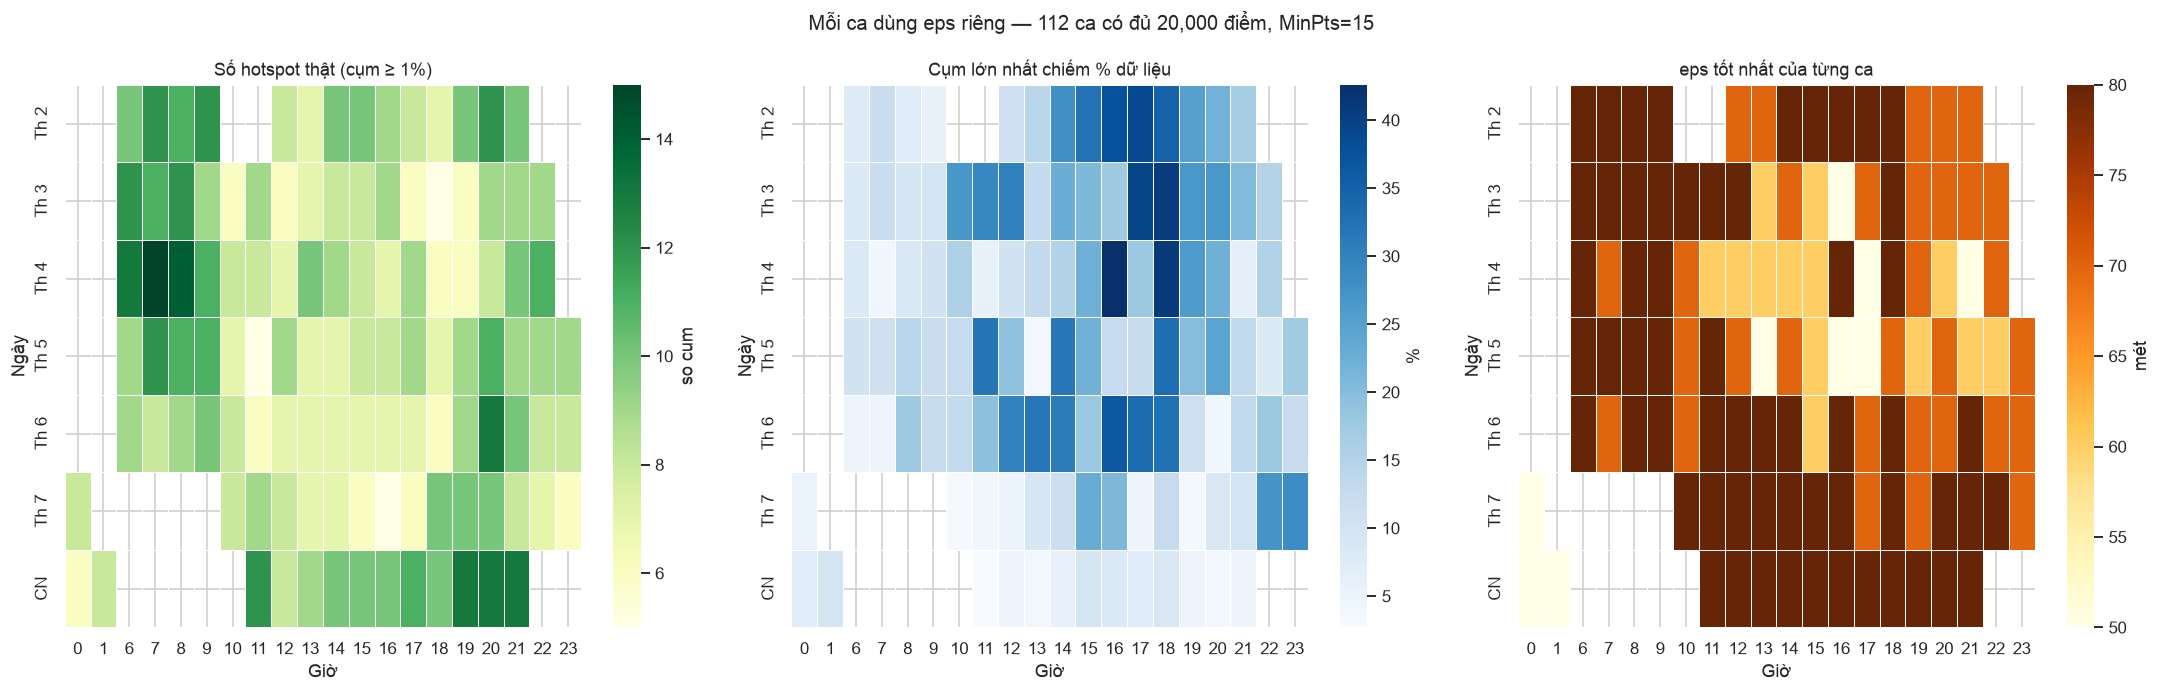

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.4))

g1 = best.pivot(index="ngay", columns="hour", values="useful").reindex(DOW)
g2 = best.pivot(index="ngay", columns="hour", values="top_share").reindex(DOW)
g3 = best.pivot(index="ngay", columns="hour", values="eps_m").reindex(DOW)

sns.heatmap(g1, cmap="YlGn", ax=axes[0], cbar_kws={"label": "so cum"}, linewidths=0.4)
axes[0].set_title("Số hotspot thật (cụm ≥ 1%)", fontsize=11.5)

sns.heatmap(g2, cmap="Blues", ax=axes[1], cbar_kws={"label": "%"}, linewidths=0.4)
axes[1].set_title("Cụm lớn nhất chiếm % dữ liệu", fontsize=11.5)

sns.heatmap(g3, cmap="YlOrBr", ax=axes[2], cbar_kws={"label": "mét"}, linewidths=0.4)
axes[2].set_title("eps tốt nhất của từng ca", fontsize=11.5)

for ax in axes:
    ax.set_xlabel("Giờ")
    ax.set_ylabel("Ngày")

plt.suptitle(f"Mỗi ca dùng eps riêng — {len(best)} ca có đủ {N_SAMPLE:,} điểm, MinPts={MIN_PTS}",
             fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "window_01_best_eps.png", bbox_inches="tight")
plt.show()

In [7]:
cols = ["ngay", "hour", "eps_m", "n_clusters", "noise_pct", "top_share", "useful"]
print("=== 8 ca nhieu hotspot that nhat ===")
print(best[best["ok"]].sort_values("useful", ascending=False).head(8)[cols].to_string(index=False))

print("\n=== 8 ca it hotspot that nhat (van dat dieu kien) ===")
print(best[best["ok"]].sort_values("useful").head(8)[cols].to_string(index=False))

=== 8 ca nhieu hotspot that nhat ===
ngay  hour  eps_m  n_clusters  noise_pct  top_share  useful
Th 4     7     70         198       39.6        4.2      15
Th 4     8     80         127       31.2        8.6      14
  CN    19     80         132       43.0        4.8      13
Th 4     6     80         162       33.2        8.4      13
Th 6    20     70         159       43.2        4.2      13
  CN    21     80         134       43.1        4.7      13
  CN    20     80         156       42.7        3.5      13
Th 3     8     80         137       32.6        9.6      12

=== 8 ca it hotspot that nhat (van dat dieu kien) ===
ngay  hour  eps_m  n_clusters  noise_pct  top_share  useful
Th 7    16     80         133       39.9       20.9       5
Th 3    18     80          71       28.6       40.7       5
Th 5    11     80         101       35.6       32.0       5
Th 3    12     80          90       35.9       30.4       6
Th 3    10     80         123       36.0       26.8       6
Th 3    

---

## 4. Câu hỏi 2: vì sao app lại không cụm được?

App mặc định dùng **200.000 điểm** (lấy mẫu từ 472.170 điểm của Thứ 2–6, 18–20h). Notebook trên chỉ dùng 20.000 để so sánh công bằng. Vậy ở mật độ thật của app thì sao?

Đây là câu hỏi then chốt — và nó thay đổi hoàn toàn kết luận.

In [8]:
app_spec = FilterSpec(weekdays=(0, 1, 2, 3, 4), hour_start=18, hour_end=20)
app_window = filter_pickups(df, app_spec)
app_sample = app_window.sample(200_000, random_state=SEED)
print(f"Ca mac dinh cua app: Th 2-6, 18-20h — {len(app_window):,} diem")
print(f"Dung mau 200.000 diem nhu app\n")

tbl = pd.DataFrame([evaluate(app_sample, e) for e in [50, 60, 70, 80, 100, 120, 150]])
print(tbl.to_string(index=False))
print(f"\n=> top_share luon {tbl['top_share'].min():.0f}-{tbl['top_share'].max():.0f}%")
print("   Doi eps KHONG giai quyet duoc o mat do nay.")

Ca mac dinh cua app: Th 2-6, 18-20h — 472,170 diem
Dung mau 200.000 diem nhu app



 eps_m  n_clusters  noise_pct  top_share  useful    ok
    50         287       11.1       76.9       2 False
    60         248        9.3       79.5       2 False
    70         229        7.8       80.7       3 False
    80         198        6.7       81.3       3 False
   100         133        5.3       81.5       5 False
   120         124        4.2       81.6       5 False
   150          93        3.2       82.1       5 False

=> top_share luon 77-82%
   Doi eps KHONG giai quyet duoc o mat do nay.


> Ở mật độ 200.000 điểm, **mọi** giá trị `eps` từ 50 đến 150 m đều cho cụm lớn nhất chiếm 86–88% dữ liệu. Nghĩa là tham số không phải vấn đề — **mật độ dữ liệu mới là vấn đề**.

Kiểm chứng bằng cách giữ nguyên `eps` và chỉ thay đổi số điểm:

=== Giu nguyen eps=70 m, chi doi so diem ===
 n_diem  eps_m  n_clusters  noise_pct  top_share  useful    ok
  10000     70          75       64.2       10.7       3  True
  20000     70         112       36.6       22.8       5  True
  30000     70         109       26.9       38.1       4  True
  60000     70         137       16.0       72.0       2 False
 100000     70         151       11.7       77.3       2 False
 200000     70         229        7.8       80.7       3 False


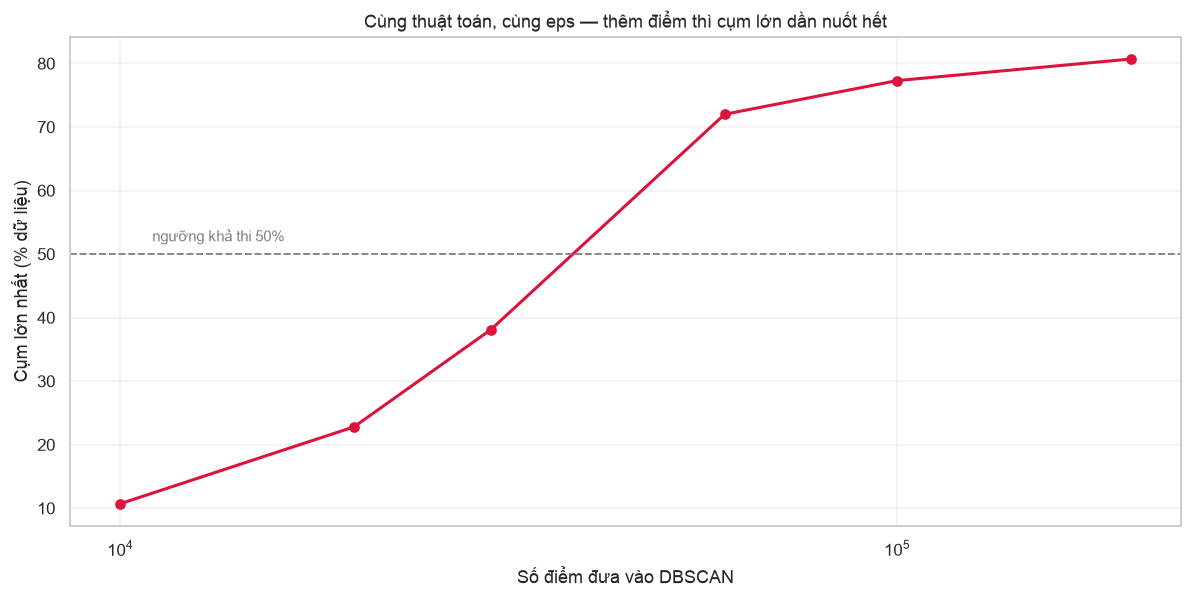

In [9]:
rows = []
for n in (10_000, 20_000, 30_000, 60_000, 100_000, 200_000):
    s = app_window.sample(n, random_state=SEED)
    rows.append({"n_diem": n, **evaluate(s, 70)})
dens = pd.DataFrame(rows)
print("=== Giu nguyen eps=70 m, chi doi so diem ===")
print(dens.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5.6))
ax.plot(dens["n_diem"], dens["top_share"], marker="o", lw=2, color="crimson")
ax.axhline(TOP_LIMIT, ls="--", color="gray", lw=1.2)
ax.text(11_000, TOP_LIMIT + 2, f"ngưỡng khả thi {TOP_LIMIT:.0f}%", fontsize=9.5, color="gray")
ax.set_xlabel("Số điểm đưa vào DBSCAN")
ax.set_ylabel("Cụm lớn nhất (% dữ liệu)")
ax.set_title("Cùng thuật toán, cùng eps — thêm điểm thì cụm lớn dần nuốt hết")
ax.set_xscale("log")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "window_02_density.png", bbox_inches="tight")
plt.show()

> Đây là kết quả quan trọng nhất của notebook. `eps` cố định 70 m, thuật toán không đổi — chỉ thêm điểm — và cụm lớn nhất nhảy mạnh. `top_share` phản ánh **mật độ dữ liệu**, không phải chất lượng thuật toán.

---

## 5. Câu hỏi 3: thu hẹp phạm vi không gian thì sao?

Nếu mật độ là nguyên nhân, thì giữ nguyên số điểm nhưng chia nhỏ phạm vi cũng phải giúp. Thử từng quận ở cùng ca điểm.

In [10]:
rows = []
for region in ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]:
    d = app_sample[app_sample["borough"] == region]
    row = {"quan": region, "n_diem": len(d)}
    for e in (60, 80, 100):
        row[f"eps={e}"] = (
            f"top {evaluate(d, e)['top_share']:5.1f}%"
            if len(d) >= 5000 else "(qua it diem de so sanh)"
        )
    rows.append(row)

print("=== Cung ca diem toi, tach theo quan ===")
print(pd.DataFrame(rows).to_string(index=False))
print()
print("=> Manhattan rut gon MOT khoi (top ~99%) o moi eps.")
print("   Brooklyn/Queens tach duoc, dung cung ca diem va cung thuat toan.")

=== Cung ca diem toi, tach theo quan ===
         quan  n_diem                   eps=60                   eps=80                  eps=100
    Manhattan  165707               top  95.9%               top  98.1%               top  98.4%
     Brooklyn   18943               top   8.9%               top  18.0%               top  27.1%
       Queens   13087               top  16.5%               top  16.9%               top  17.0%
        Bronx     887 (qua it diem de so sanh) (qua it diem de so sanh) (qua it diem de so sanh)
Staten Island      21 (qua it diem de so sanh) (qua it diem de so sanh) (qua it diem de so sanh)

=> Manhattan rut gon MOT khoi (top ~99%) o moi eps.
   Brooklyn/Queens tach duoc, dung cung ca diem va cung thuat toan.


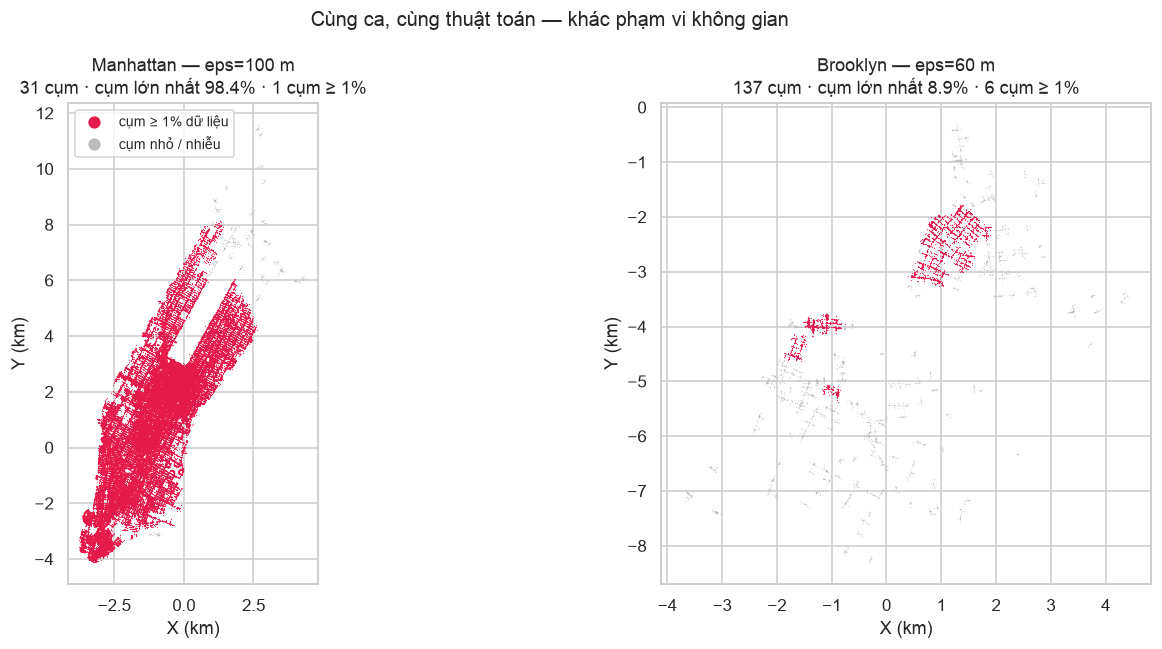

In [11]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, region, eps in [(axes[0], "Manhattan", 100), (axes[1], "Brooklyn", 60)]:
    d = app_sample[app_sample["borough"] == region]
    r = run_dbscan(d, eps, MIN_PTS)
    e = evaluate(d, eps)
    lab = d.assign(_label=r.labels)
    cl = lab[lab["_label"] != -1]
    sizes = cl["_label"].value_counts()
    big = set(sizes[sizes >= 0.01 * len(d)].index)

    for label, g in cl.groupby("_label"):
        ax.scatter(g["x_m"] / 1000, g["y_m"] / 1000, s=0.6,
                   c="#e6194b" if label in big else "#bbbbbb",
                   alpha=0.85 if label in big else 0.3, linewidths=0)
    ax.set_aspect("equal")
    ax.set_title(f"{region} — eps={eps} m\n"
                 f"{len(sizes)} cụm · cụm lớn nhất {e['top_share']}% · {e['useful']} cụm ≥ 1%",
                 fontsize=11.5)
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")

axes[0].legend(handles=[
    Line2D([], [], marker="o", ls="", color="#e6194b", label="cụm ≥ 1% dữ liệu", markersize=7),
    Line2D([], [], marker="o", ls="", color="#bbbbbb", label="cụm nhỏ / nhiễu", markersize=7)],
    loc="upper left", fontsize=9)

plt.suptitle("Cùng ca, cùng thuật toán — khác phạm vi không gian", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "window_03_region.png", bbox_inches="tight")
plt.show()

---

## 6. Vực thẳm của `eps`

Với một ca **mỏng** (số điểm vừa đủ), đường cong `eps` cho thấy rõ vùng dùng được.

=== Ca toi Th 2-6 18-20h, mau 20.000 diem ===
 eps_m  n_clusters  noise_pct  top_share  useful    ok
    20          22       95.2        0.8       0 False
    30          91       82.6        1.1       1 False
    40         134       70.6        1.8       3  True
    50         154       56.9       12.8       2 False
    60         126       46.5       20.5       5  True
    70         108       36.1       30.8       7  True
    80          79       29.6       37.3       5  True
    90          54       24.9       60.1       2 False
   100          50       22.1       66.1       2 False
   110          38       19.4       70.7       2 False
   120          40       17.2       73.2       3 False
   130          35       16.0       75.8       2 False
   140          35       14.6       77.6       2 False


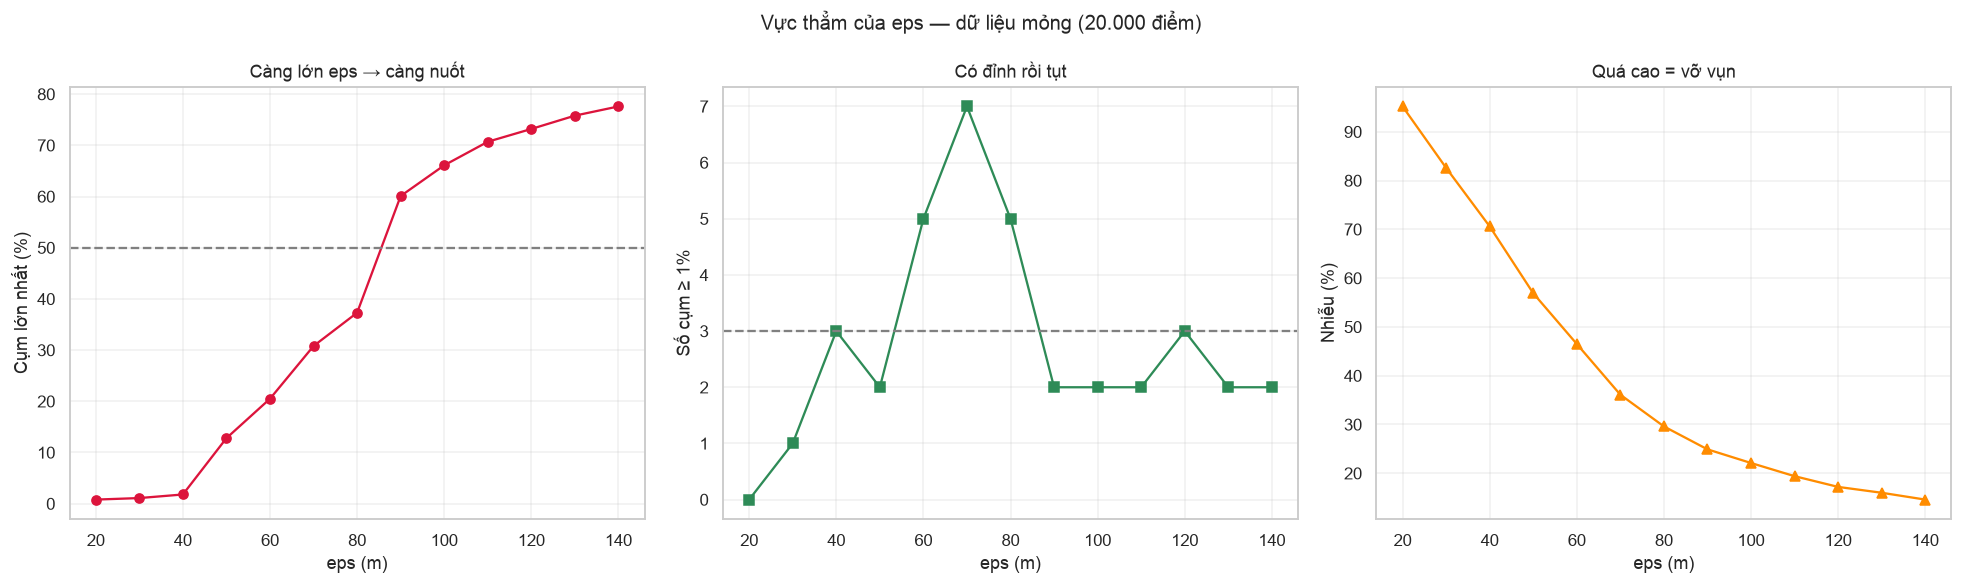

In [12]:
thin = app_sample.sample(20_000, random_state=SEED)
fine = pd.DataFrame([evaluate(thin, e) for e in range(20, 141, 10)])

print("=== Ca toi Th 2-6 18-20h, mau 20.000 diem ===")
print(fine.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.4))
axes[0].plot(fine["eps_m"], fine["top_share"], marker="o", color="crimson")
axes[0].axhline(TOP_LIMIT, ls="--", color="gray")
axes[0].set_xlabel("eps (m)"); axes[0].set_ylabel("Cụm lớn nhất (%)")
axes[0].set_title("Càng lớn eps → càng nuốt"); axes[0].grid(alpha=0.3)

axes[1].plot(fine["eps_m"], fine["useful"], marker="s", color="seagreen")
axes[1].axhline(MIN_USEFUL, ls="--", color="gray")
axes[1].set_xlabel("eps (m)"); axes[1].set_ylabel("Số cụm ≥ 1%")
axes[1].set_title("Có đỉnh rồi tụt"); axes[1].grid(alpha=0.3)

axes[2].plot(fine["eps_m"], fine["noise_pct"], marker="^", color="darkorange")
axes[2].set_xlabel("eps (m)"); axes[2].set_ylabel("Nhiễu (%)")
axes[2].set_title("Quá cao = vỡ vụn"); axes[2].grid(alpha=0.3)

plt.suptitle("Vực thẳm của eps — dữ liệu mỏng (20.000 điểm)", fontsize=13)
plt.tight_layout()
plt.savefig(OUT / "window_04_eps_cliff.png", bbox_inches="tight")
plt.show()

---

## 7. Bản đồ các cấu hình dùng được

Vẽ 3 cấu hình: Brooklyn và Queens (tách được) so với Manhattan (một khối) — để thấy bằng mắt.

In [13]:
from hotspot.figures import borough_labels, load_borough_rings, plot_clusters, projection_origin

lat0, lon0 = projection_origin(OUT / "preprocess_report.json")
rings = load_borough_rings(ROOT / "data" / "raw", lat0, lon0)

PICKS = [("Brooklyn", 60), ("Queens", 60), ("Manhattan", 100)]
for borough, eps in PICKS:
    d = app_sample[app_sample["borough"] == borough]
    res = run_dbscan(d, eps, MIN_PTS)
    e = evaluate(d, eps)

    fig, ax = plt.subplots(figsize=(10, 10.5))
    plot_clusters(ax, d, res, rings, max_points_per_cluster=1500, max_noise=4000)
    borough_labels(ax, rings, fontsize=12, clip_to_view=True)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{borough} — ca điểm Thứ 2–6 18–20h, eps={eps} m, MinPts={MIN_PTS}\n"
                 f"{res.n_clusters} cụm · cụm lớn nhất {e['top_share']}% · "
                 f"{e['useful']} cụm ≥ 1% dữ liệu · {len(d):,} điểm", fontsize=12)
    path = OUT / f"window_05_{borough}.png"
    fig.savefig(path, dpi=140, bbox_inches="tight")
    plt.close(fig)
    print(f"  -> {path.name}  (top {e['top_share']}%, {e['useful']} cum lon)")

  -> window_05_Brooklyn.png  (top 8.9%, 6 cum lon)


  -> window_05_Queens.png  (top 16.5%, 10 cum lon)


  -> window_05_Manhattan.png  (top 98.4%, 1 cum lon)


---

## Kết luận

*Số liệu dưới đây lấy từ lần chạy này; chạy lại với seed khác sẽ dao động vài điểm phần trăm.*

### 1. Không có khoảng thời gian nào giải được

112 ca có đủ dữ liệu để so sánh, mỗi ca thử 5 giá trị `eps`: **112/112 ca đều có ít nhất một `eps` đạt điều kiện**.

Nói cách khác: câu hỏi "lúc nào thì phân cụm được" có câu trả lời là **lúc nào cũng được, nếu chọn đúng bán kính**. Đổi khung giờ không giải quyết được vấn đề của bạn.

Phân tách biến động của `top_share`: `eps` chiếm 41,4%, ca (ngày × giờ) chiếm 39,5% — gần như bằng nhau.

### 2. Nguyên nhân thật là mật độ dữ liệu

Giữ nguyên thuật toán và `eps = 70 m`, chỉ thay đổi số điểm đầu vào (ca điểm Thứ 2–6, 18–20h):

| Số điểm | Cụm lớn nhất | Cụm ≥ 1% | Đạt yêu cầu |
|---|---|---|---|
| 10.000 | 10,7% | 3 | ✓ |
| 20.000 | 22,8% | 5 | ✓ |
| 30.000 | 38,1% | 4 | ✓ |
| 60.000 | 72,0% | 2 | ✗ |
| 100.000 | 77,3% | 2 | ✗ |
| 200.000 | 80,7% | 3 | ✗ |

Ở **200.000 điểm** — đúng mật độ app đang dùng — mọi `eps` từ 50 đến 150 m đều cho cụm lớn nhất **77–82%**, không giá trị nào đạt yêu cầu. Vùng khả thi nằm **dưới khoảng 40.000 điểm** trên phạm vi 5 quận.

**Đây là lý do bạn thấy "mật độ quá dày, không cluster được". Nhận xét đó chính xác — chỉ là nguyên nhân nằm ở lượng dữ liệu đưa vào, không phải ở khung giờ.**

### 3. Phạm vi không gian quyết định nhiều nhất

Cùng ca điểm, cùng 200.000 điểm, cùng thuật toán:

| Quận | Số điểm | `top_share` ở eps 60 / 80 / 100 |
|---|---|---|
| Manhattan | 165.707 | 95,9% / 98,1% / 98,4% |
| Brooklyn | 18.943 | 8,9% / 18,0% / 27,1% |
| Queens | 13.087 | 16,5% / 16,9% / 17,0% |

Manhattan gộp thành **một khối duy nhất ở mọi `eps`**. Brooklyn và Queens tách ra 6–10 hotspot thật.

Chênh lệch nằm ở mật độ không gian: Manhattan nhận 165.707 điển trong diện tích nhỏ, Brooklyn chỉ 18.943.

### 4. Vực thẳm của `eps`

Trên mẫu 20.000 điểm của ca điểm:

| eps | cụm | nhiễu | cụm lớn nhất | cụm ≥1% |
|---|---|---|---|---|
| 40 m | 134 | 70,6% | 1,8% | 3 |
| 60 m | 126 | 46,5% | 20,5% | 5 |
| 70 m | 108 | 36,1% | 30,8% | 7 |
| 80 m | 79 | 29,6% | 37,3% | 5 |
| 90 m | 54 | 24,9% | **60,1%** | 2 |
| 100 m | 50 | 22,1% | **66,1%** | 2 |

- **Dưới ~40 m**: nhiễu trên 70%, cụm lớn nhất quá nhỏ để là hotspot.
- **60–80 m**: vùng dùng được — 5–7 hotspot thật.
- **Trên ~90 m**: dữ liệu dính lại, hết tách được.

`eps = 100 m` mà tôi dùng ở các notebook trước nằm **trên** vực thẳm. Đây là lý do kết quả ở đó không dùng được.

### 5. Khuyến nghị

Theo thứ tự ưu tiên:

1. **Giảm số điểm** đưa vào DBSCAN về khoảng 20–30k.
2. **Thu hẹp phạm vi** — bỏ Manhattan, phân tích Brooklyn/Queens.
3. **Đặt `eps` trong khoảng 60–80 m**, chọn theo đường cong k-distance.

Nếu bắt buộc phải chạy trên 200k điểm của Manhattan thì phải chấp nhận kết luận "Manhattan là một hotspot duy nhất". Đó **là câu trả lời đúng** của thuật toán, không phải lỗi của thuật toán.

### 6. Việc chưa làm

- Chưa thử **HDBSCAN** (thích ứng mật độ cục bộ) — có thể giải quyết đúng vấn đề này mà không cần bớt dữ liệu.
- Chưa tách Manhattan theo khu vực nhỏ hơn (ví dụ theo chức năng) để tìm mật độ thấp hơn.
- Chưa kiểm chứng các cụm tìm được có đúng là điểm dừng khách thật trên hiện trường.